# Module 1 — Data Cleaning & Exploratory Data Analysis (EDA)
**Project:** IoT and ML Based Carbon Credit Estimation and Monitoring System for Agriculture and Industry

**Input:** `carbon_credit_synthetic_dataset.csv`
**Output:** `cleaned_carbon_credit_dataset.csv` + EDA plots (inline + saved as PNG)


## 0. Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

INPUT_FILE = "D:/GreenAgri/GreenAgri_CarbonCredit_Estimator/data/raw/carbon_credit_synthetic_dataset.csv"
OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## Step 1: Load Data

In [11]:
df = pd.read_csv(INPUT_FILE, parse_dates=["Date"])
print(f"Initial shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Initial shape: 533 rows x 15 columns


,Record_ID,Date,Location,Crop_Type,Farming_Practice,Soil_Moisture_%,Temperature_C,Humidity_%,Soil_pH,Nitrogen_kg_per_ha,Gas_Sensor_ppm,Energy_Consumption_kWh,Carbon_Emission_kgCO2,Carbon_Saved_kgCO2,Carbon_Credit_Score
0,REC0111,2024-04-20,Nagpur_Farm_A,Wheat,Organic Farming,15.81,NaN,57.14,6.30,41.84,452.12,73.53,5.29,144.71,0.1447
1,REC0245,2024-09-01,Chandrapur_Farm_C,Rice,Conventional Tillage,23.00,30.59,50.26,5.85,74.26,197.64,113.09,57.18,92.82,0.0928
2,REC0335,2024-11-30,Amravati_Field_2,Sugarcane,Conventional Tillage,NaN,27.83,62.23,6.07,63.36,NaN,175.98,64.69,85.31,0.0853
3,REC0440,2025-03-15,Wardha_Field_1,NaN,Conventional Tillage,34.44,25.18,71.02,6.57,25.90,368.60,131.71,29.45,120.55,0.1206
4,REC0234,2024-08-21,Nagpur_Farm_A,Sugarcane,No-Till,28.48,19.49,98.70,6.29,63.39,NaN,196.46,28.78,121.22,0.1212


## Step 2: Initial Inspection

In [12]:
print("Data types:")
print(df.dtypes)


Data types:
Record_ID                         object
Date                      datetime64[ns]
Location                          object
Crop_Type                         object
Farming_Practice                  object
Soil_Moisture_%                  float64
Temperature_C                    float64
Humidity_%                       float64
Soil_pH                          float64
Nitrogen_kg_per_ha               float64
Gas_Sensor_ppm                   float64
Energy_Consumption_kWh           float64
Carbon_Emission_kgCO2            float64
Carbon_Saved_kgCO2               float64
Carbon_Credit_Score              float64
dtype: object


In [13]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Record_ID                  0
Date                       0
Location                   0
Crop_Type                 35
Farming_Practice           0
Soil_Moisture_%           32
Temperature_C             25
Humidity_%                41
Soil_pH                   24
Nitrogen_kg_per_ha        43
Gas_Sensor_ppm            36
Energy_Consumption_kWh    43
Carbon_Emission_kgCO2      0
Carbon_Saved_kgCO2         0
Carbon_Credit_Score        0
dtype: int64


In [14]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated Record_IDs:", df['Record_ID'].duplicated().sum())


Fully duplicated rows: 25
Duplicated Record_IDs: 25


In [15]:
df.describe()


,Date,Soil_Moisture_%,Temperature_C,Humidity_%,Soil_pH,Nitrogen_kg_per_ha,Gas_Sensor_ppm,Energy_Consumption_kWh,Carbon_Emission_kgCO2,Carbon_Saved_kgCO2,Carbon_Credit_Score
count,533,501.000000,508.000000,492.000000,509.000000,490.000000,497.000000,490.000000,533.000000,533.000000,533.000000
mean,2024-09-08 04:49:04.840525568,35.021517,28.150689,61.923313,6.535894,49.537673,402.497445,119.390633,32.217467,117.782533,0.117780
min,2024-01-01 00:00:00,2.590000,14.520000,16.560000,4.440000,4.710000,160.710000,2.820000,-7.560000,41.670000,0.041700
25%,2024-05-08 00:00:00,27.920000,25.025000,51.502500,6.070000,39.920000,349.170000,90.092500,19.820000,108.280000,0.108300
50%,2024-09-07 00:00:00,35.050000,28.145000,61.940000,6.540000,49.805000,403.060000,120.245000,28.210000,121.790000,0.121800
75%,2025-01-12 00:00:00,41.300000,31.242500,71.437500,7.000000,59.965000,453.470000,148.135000,41.720000,130.180000,0.130200
max,2025-05-14 00:00:00,73.530000,41.160000,99.030000,8.740000,96.650000,714.100000,234.740000,108.330000,157.560000,0.157600
std,NaN,9.915292,4.903978,14.903976,0.691166,14.256706,80.882469,41.183869,18.867956,18.867956,0.018867


## Step 3: Remove Duplicates

In [16]:
before = df.shape[0]
df = df.drop_duplicates(subset=df.columns.difference(['Record_ID']), keep='first')
after = df.shape[0]
print(f"Removed {before - after} duplicate rows (based on all columns except Record_ID).")
print(f"Shape after de-duplication: {df.shape}")


Removed 33 duplicate rows (based on all columns except Record_ID).
Shape after de-duplication: (500, 15)


## Step 4: Handle Missing Values

- Numeric sensor columns -> imputed with **median** (robust to outliers, standard practice for sensor data)
- Categorical column (`Crop_Type`) -> imputed with **mode**


In [17]:
numeric_cols = [
    "Soil_Moisture_%", "Temperature_C", "Humidity_%", "Soil_pH",
    "Nitrogen_kg_per_ha", "Gas_Sensor_ppm", "Energy_Consumption_kWh"
]

print("Missing values BEFORE imputation:")
print(df[numeric_cols + ["Crop_Type"]].isnull().sum())


Missing values BEFORE imputation:
Soil_Moisture_%           31
Temperature_C             23
Humidity_%                39
Soil_pH                   22
Nitrogen_kg_per_ha        43
Gas_Sensor_ppm            33
Energy_Consumption_kWh    40
Crop_Type                 32
dtype: int64


In [18]:
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  -> Filled '{col}' nulls with median = {median_val:.2f}")

mode_val = df["Crop_Type"].mode()[0]
df["Crop_Type"] = df["Crop_Type"].fillna(mode_val)
print(f"  -> Filled 'Crop_Type' nulls with mode = '{mode_val}'")


  -> Filled 'Soil_Moisture_%' nulls with median = 35.05
  -> Filled 'Temperature_C' nulls with median = 28.13
  -> Filled 'Humidity_%' nulls with median = 61.83
  -> Filled 'Soil_pH' nulls with median = 6.51
  -> Filled 'Nitrogen_kg_per_ha' nulls with median = 49.82
  -> Filled 'Gas_Sensor_ppm' nulls with median = 403.06
  -> Filled 'Energy_Consumption_kWh' nulls with median = 119.20
  -> Filled 'Crop_Type' nulls with mode = 'Rice'


In [19]:
print("Missing values AFTER imputation:")
df[numeric_cols + ["Crop_Type"]].isnull().sum()


Missing values AFTER imputation:


Soil_Moisture_%           0
Temperature_C             0
Humidity_%                0
Soil_pH                   0
Nitrogen_kg_per_ha        0
Gas_Sensor_ppm            0
Energy_Consumption_kWh    0
Crop_Type                 0
dtype: int64

## Step 5: Outlier Detection (IQR Method)

Reported only, not auto-removed, since some "outliers" may be genuine extreme sensor readings worth keeping.

In [20]:
for col in numeric_cols + ["Carbon_Emission_kgCO2", "Carbon_Credit_Score"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"  {col}: {len(outliers)} potential outliers "
          f"(valid range ~[{lower:.2f}, {upper:.2f}])")


  Soil_Moisture_%: 6 potential outliers (valid range ~[10.02, 59.43])
  Temperature_C: 10 potential outliers (valid range ~[16.10, 40.19])
  Humidity_%: 7 potential outliers (valid range ~[24.35, 98.20])
  Soil_pH: 10 potential outliers (valid range ~[4.85, 8.23])
  Nitrogen_kg_per_ha: 5 potential outliers (valid range ~[13.80, 85.98])
  Gas_Sensor_ppm: 9 potential outliers (valid range ~[204.28, 597.09])
  Energy_Consumption_kWh: 2 potential outliers (valid range ~[13.90, 221.40])
  Carbon_Emission_kgCO2: 22 potential outliers (valid range ~[-12.91, 74.65])
  Carbon_Credit_Score: 22 potential outliers (valid range ~[0.08, 0.16])


## Step 6: Feature Engineering

In [21]:
df["Month"] = df["Date"].dt.month_name()
df["Emission_Category"] = pd.cut(
    df["Carbon_Emission_kgCO2"],
    bins=[-np.inf, 50, 100, np.inf],
    labels=["Low", "Medium", "High"]
)
print("Added 'Month' and 'Emission_Category' columns.")
df.head()


Added 'Month' and 'Emission_Category' columns.


,Record_ID,Date,Location,Crop_Type,Farming_Practice,Soil_Moisture_%,Temperature_C,Humidity_%,Soil_pH,Nitrogen_kg_per_ha,Gas_Sensor_ppm,Energy_Consumption_kWh,Carbon_Emission_kgCO2,Carbon_Saved_kgCO2,Carbon_Credit_Score,Month,Emission_Category
0,REC0111,2024-04-20,Nagpur_Farm_A,Wheat,Organic Farming,15.81,28.13,57.14,6.30,41.84,452.12,73.53,5.29,144.71,0.1447,April,Low
1,REC0245,2024-09-01,Chandrapur_Farm_C,Rice,Conventional Tillage,23.00,30.59,50.26,5.85,74.26,197.64,113.09,57.18,92.82,0.0928,September,Medium
2,REC0335,2024-11-30,Amravati_Field_2,Sugarcane,Conventional Tillage,35.05,27.83,62.23,6.07,63.36,403.06,175.98,64.69,85.31,0.0853,November,Medium
3,REC0440,2025-03-15,Wardha_Field_1,Rice,Conventional Tillage,34.44,25.18,71.02,6.57,25.90,368.60,131.71,29.45,120.55,0.1206,March,Low
4,REC0234,2024-08-21,Nagpur_Farm_A,Sugarcane,No-Till,28.48,19.49,98.70,6.29,63.39,403.06,196.46,28.78,121.22,0.1212,August,Low


## Step 7: Save Cleaned Dataset

In [22]:
cleaned_path = "cleaned_carbon_credit_dataset.csv"
df.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved to: {cleaned_path}")
print(f"Final shape: {df.shape[0]} rows x {df.shape[1]} columns")


Cleaned dataset saved to: cleaned_carbon_credit_dataset.csv
Final shape: 500 rows x 17 columns


## Step 8: Exploratory Data Analysis (EDA)

### 8.1 Correlation Heatmap

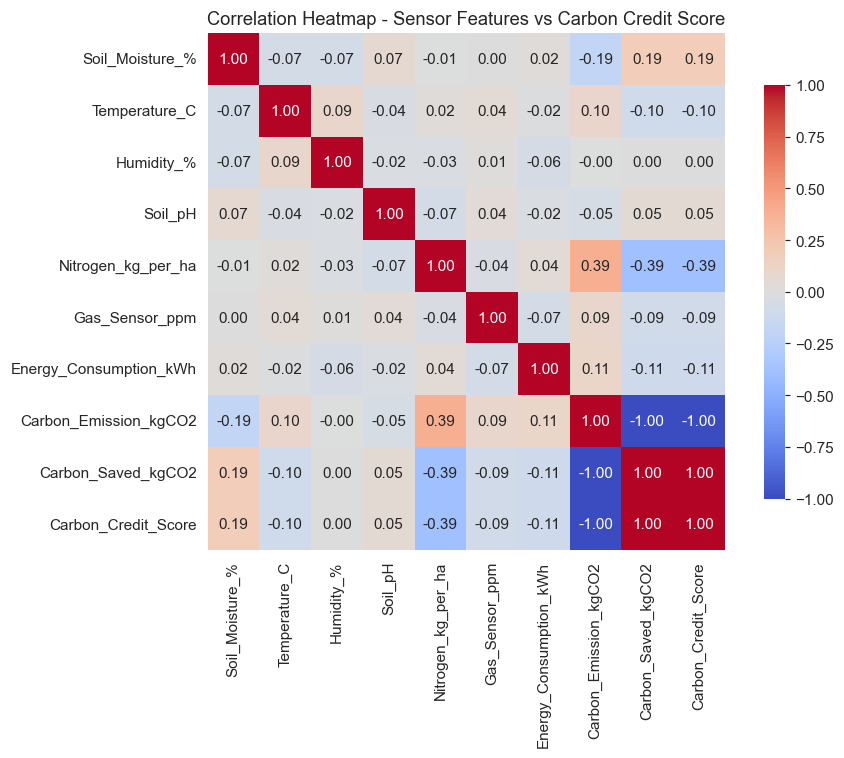

In [23]:
plt.figure(figsize=(9, 7))
corr_cols = numeric_cols + ["Carbon_Emission_kgCO2", "Carbon_Saved_kgCO2", "Carbon_Credit_Score"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap - Sensor Features vs Carbon Credit Score")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_correlation_heatmap.png")
plt.show()


### 8.2 Distribution of Carbon Credit Score

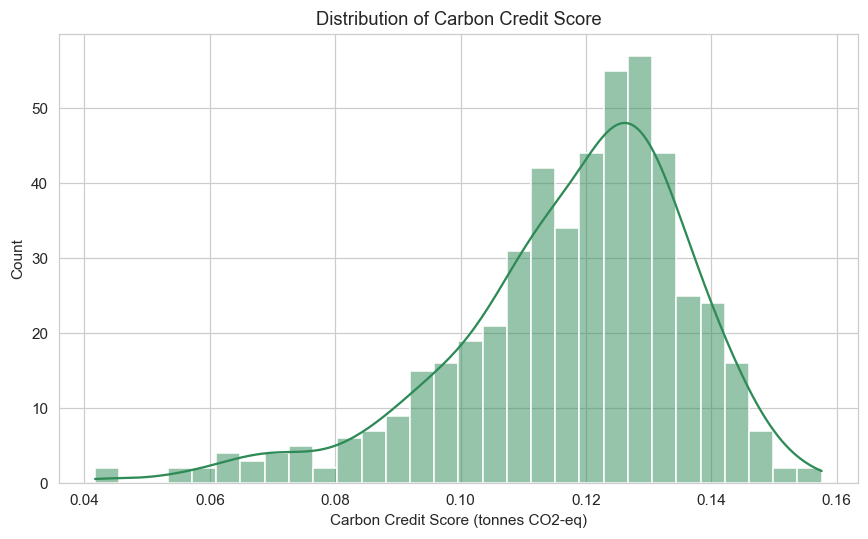

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Carbon_Credit_Score"], kde=True, color="seagreen", bins=30)
plt.title("Distribution of Carbon Credit Score")
plt.xlabel("Carbon Credit Score (tonnes CO2-eq)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_carbon_credit_distribution.png")
plt.show()


### 8.3 Carbon Emission by Farming Practice

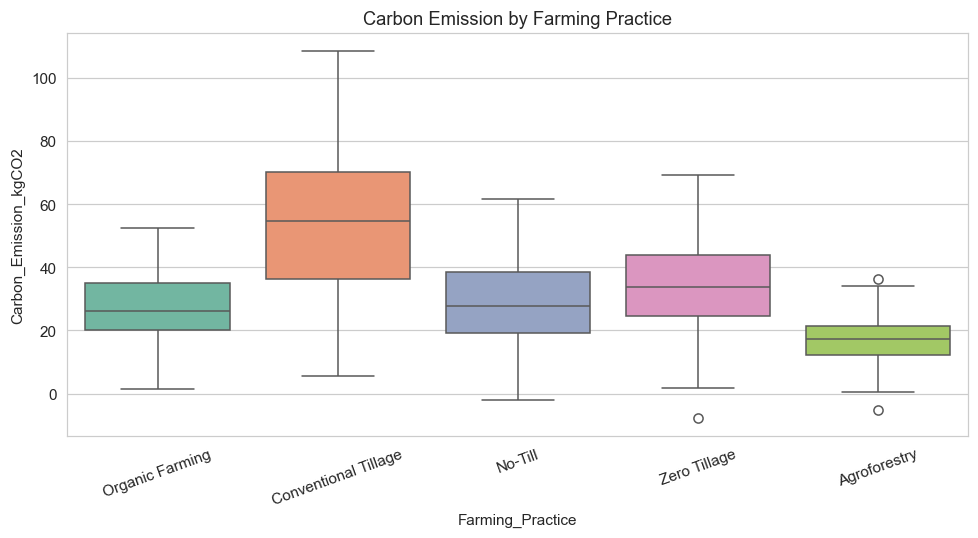

In [25]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Farming_Practice", y="Carbon_Emission_kgCO2",
            hue="Farming_Practice", palette="Set2", legend=False)
plt.title("Carbon Emission by Farming Practice")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_emission_by_practice.png")
plt.show()


### 8.4 Carbon Credit Score by Crop Type

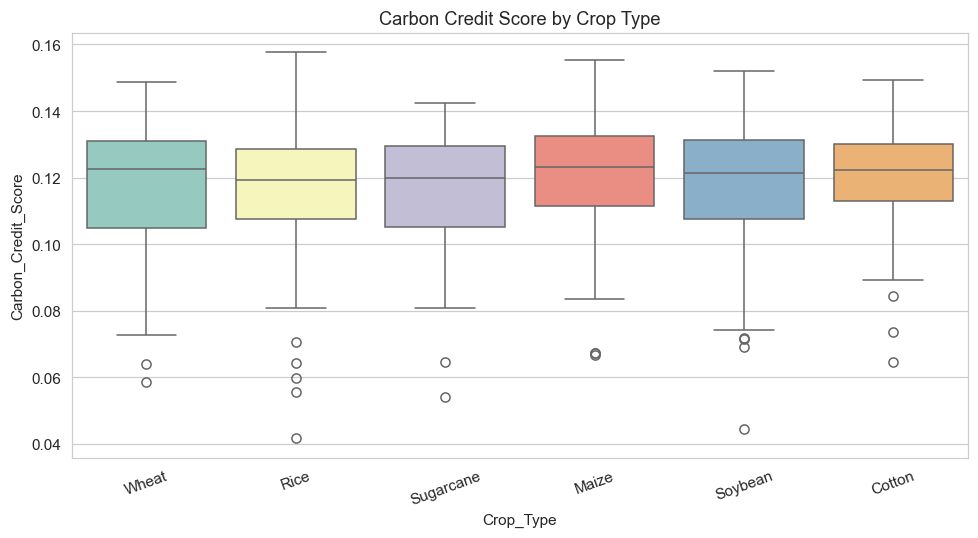

In [26]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Crop_Type", y="Carbon_Credit_Score",
            hue="Crop_Type", palette="Set3", legend=False)
plt.title("Carbon Credit Score by Crop Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_credit_by_crop.png")
plt.show()


### 8.5 Soil Moisture vs Carbon Emission

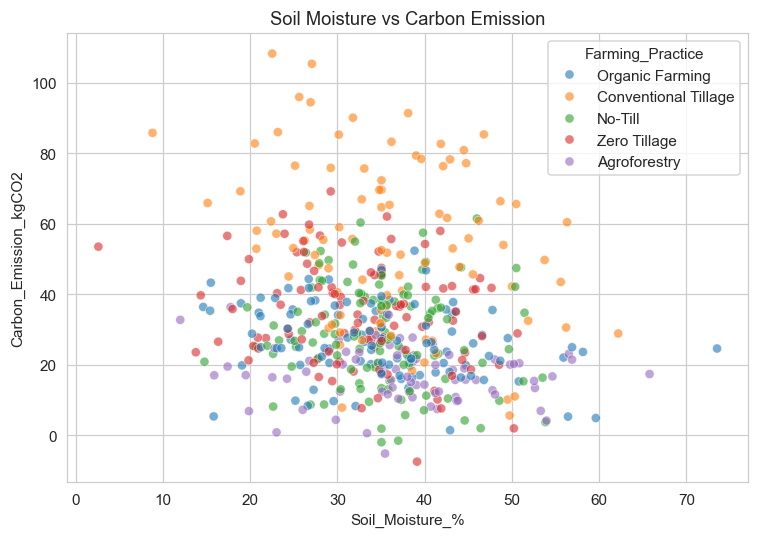

In [27]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Soil_Moisture_%", y="Carbon_Emission_kgCO2",
                 hue="Farming_Practice", alpha=0.6)
plt.title("Soil Moisture vs Carbon Emission")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_soilmoisture_vs_emission.png")
plt.show()


### 8.6 Count of Records by Emission Category

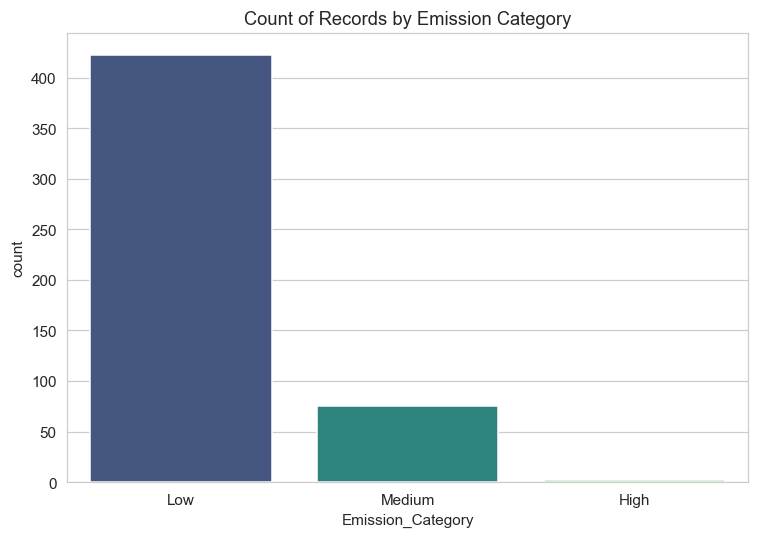

In [28]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Emission_Category", hue="Emission_Category",
              palette="viridis", order=["Low", "Medium", "High"], legend=False)
plt.title("Count of Records by Emission Category")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_emission_category_count.png")
plt.show()


## Summary

- Removed duplicate sensor log entries
- Imputed missing sensor readings (median) and missing crop labels (mode)
- Flagged outliers using the IQR method for transparency
- Engineered `Month` and `Emission_Category` as extra features
- Saved a clean, ML-ready dataset: `cleaned_carbon_credit_dataset.csv`
- Produced 6 EDA visualizations to understand feature relationships before model training (next step: Module 1 ML model)
